In [1]:
import pandas as pd

df = pd.read_csv('data/track_genre_mapping.csv')
print(df.shape)
df.head()

(8000, 5)


,track_id,genre,filepath,file_exists,filesize
0,2,Hip-Hop,data/fma_small\000\000002.mp3,True,960738
1,5,Hip-Hop,data/fma_small\000\000005.mp3,True,961580
2,10,Pop,data/fma_small\000\000010.mp3,True,721040
3,140,Folk,data/fma_small\000\000140.mp3,True,480497
4,141,Folk,data/fma_small\000\000141.mp3,True,480945


In [2]:
import librosa

sample_path = df.loc[0, 'filepath']
y, sr = librosa.load(sample_path, sr=22050)

print("Durasi:", librosa.get_duration(y=y, sr=sr), "detik")
print("Sample rate:", sr)
print("Jumlah sample:", len(y))

Durasi: 29.976598639455784 detik
Sample rate: 22050
Jumlah sample: 660984


Matplotlib is building the font cache; this may take a moment.


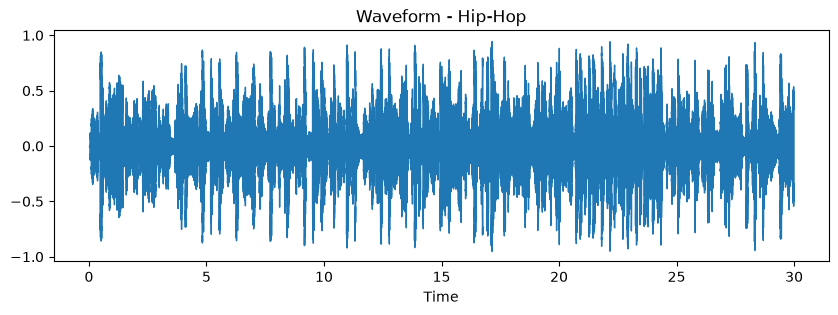

In [3]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(10, 3))
librosa.display.waveshow(y, sr=sr)
plt.title(f"Waveform - {df.loc[0, 'genre']}")
plt.show()

In [4]:
def load_audio_safe(filepath, sr=22050):
    try:
        y, sr = librosa.load(filepath, sr=sr)
        return y, sr
    except Exception as e:
        print(f"Gagal load {filepath}: {e}")
        return None, None

In [5]:
def segment_audio(y, sr, clip_duration=3):
    clip_length = clip_duration * sr
    n_clips = len(y) // clip_length
    
    clips = []
    for i in range(n_clips):
        clip = y[i*clip_length : (i+1)*clip_length]
        clips.append(clip)
    
    return clips

In [6]:
clips = segment_audio(y, sr, clip_duration=3)
print("Jumlah klip:", len(clips))
print("Panjang tiap klip:", len(clips[0]), "sample")

Jumlah klip: 9
Panjang tiap klip: 66150 sample


In [7]:
import numpy as np

def normalize_audio(y):
    return y / np.max(np.abs(y)) if np.max(np.abs(y)) > 0 else y

In [8]:
def preprocess_track(filepath, sr=22050, clip_duration=3):
    y, sr = load_audio_safe(filepath, sr=sr)
    if y is None:
        return None
    
    y = normalize_audio(y)
    clips = segment_audio(y, sr, clip_duration=clip_duration)
    
    return clips

In [9]:
from tqdm import tqdm

results = []
failed_files = []

for idx, row in tqdm(df.iterrows(), total=len(df)):
    y, sr = load_audio_safe(row['filepath'])
    
    if y is None:
        failed_files.append(row['filepath'])
        continue
    
    y = normalize_audio(y)
    clips = segment_audio(y, sr, clip_duration=3)
    
    results.append({
        'track_id': row['track_id'],
        'genre': row['genre'],
        'n_clips': len(clips),
        'duration_sec': len(y) / sr
    })

 55%|█████▌    | 4423/8000 [17:56<12:33,  4.75it/s]C:\Users\ASUS\AppData\Local\Temp\ipykernel_7892\2949846081.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(filepath, sr=sr)
C:\Users\ASUS\AppData\Roaming\Python\Python314\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 55%|█████▌    | 4426/8000 [17:56<07:04,  8.42it/s]

Gagal load data/fma_small\098\098565.mp3: 
Gagal load data/fma_small\098\098567.mp3: 
Gagal load data/fma_small\098\098569.mp3: 


 56%|█████▌    | 4472/8000 [18:05<08:25,  6.99it/s]

Gagal load data/fma_small\099\099134.mp3: 


 61%|██████▏   | 4905/8000 [19:51<07:48,  6.61it/s]

Gagal load data/fma_small\108\108925.mp3: 


 87%|████████▋ | 6967/8000 [27:57<02:19,  7.41it/s]

Gagal load data/fma_small\133\133297.mp3: 


100%|██████████| 8000/8000 [31:53<00:00,  4.18it/s]


In [10]:
print("Jumlah file gagal load:", len(failed_files))
print("Jumlah file berhasil:", len(results))

result_df = pd.DataFrame(results)
result_df.head()

Jumlah file gagal load: 6
Jumlah file berhasil: 7994


,track_id,genre,n_clips,duration_sec
0,2,Hip-Hop,9,29.976599
1,5,Hip-Hop,10,30.002721
2,10,Pop,9,29.976599
3,140,Folk,9,29.976599
4,141,Folk,9,29.976599


In [11]:
print("Total klip yang akan dihasilkan:", result_df['n_clips'].sum())
result_df['n_clips'].value_counts()

Total klip yang akan dihasilkan: 75296


n_clips
9     4644
10    3350
Name: count, dtype: int64

In [12]:
result_df['duration_sec'].describe()

count    7994.000000
mean       29.988181
std         0.012650
min        29.964580
25%        29.976599
50%        29.976599
75%        30.002721
max        30.002721
Name: duration_sec, dtype: float64

In [13]:
if failed_files:
    pd.Series(failed_files).to_csv('data/failed_files.csv', index=False)
    print("Daftar file gagal disimpan.")

Daftar file gagal disimpan.


In [14]:
df_clean = df[df['track_id'].isin(result_df['track_id'])].reset_index(drop=True)
df_clean.to_csv('data/track_genre_mapping_clean.csv', index=False)

print("Data bersih siap untuk ekstraksi fitur:", df_clean.shape)

Data bersih siap untuk ekstraksi fitur: (7994, 5)
